# Projection Accuracy: How Good Were the Preseason Projections?
*Justin McKendry*

---

## Purpose

Every other notebook in this project treats ESPN's preseason `projected_points` as a
trustworthy input - it's the basis for `proj_vorp` in the live draft tool (`src/scoring.py`),
the target-adjacent feature in NB04's regression, and the offline `players.json` export.
This notebook asks the question that assumption rests on: **how accurate are those
projections in the first place?**

We compare `projected_points` (recorded before the season) against `points` (the real
season outcome) for every player ESPN tracked stats for, across every season on record
(2020-2025), and look at:

- Overall accuracy (RMSE, MAE, R²) and whether it's improving or getting worse over time
- Accuracy broken out by position, since projecting a QB's workload is a very different
  problem than projecting a kicker's
- Systematic bias - are projections, on average, over- or under-shooting?
- The biggest individual misses (boom/bust), to put the aggregate numbers in concrete terms

This is a standalone, informational analysis - it isn't wired into the live scoring or the
public site this round, but it's a direct, honest answer to "how much should I trust the
number next to a player's name on draft day?" 

### Setup

In [1]:
import sys
sys.path.insert(0, "..")  # repo root, so `src.*` is importable alongside notebooks/config.py

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sqlalchemy import create_engine
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from config import CURRENT_SEASON, POSITIONS
from utils import load_projection_actuals
from IPython.display import display

# --- Configuration for Jupyter ---
%config InlineBackend.figure_formats = ['svg']

In [2]:
engine = create_engine("sqlite:///../data/fantasy_data.db")

## 1. Build the multi-season dataset

One row per player-season with both a preseason projection and a real outcome on record.
`load_projection_actuals` (`notebooks/utils.py`) pulls straight from `players_stats` rather
than joining through draft/ADP tables, so it covers every season back to 2020 - not just the
2022+ seasons this league has ADP data for.

**Data quality caveat:** the 2023 season has a real extraction gap where `projected_points`
was recorded as `0.0` for nearly every player (e.g. Patrick Mahomes 2023 shows
`points=267.0` but `projected_points=0.0`) - not a legitimate zero projection.
`load_projection_actuals` filters these out (`projected_points != 0`) so they don't
swamp that year's error metrics with the entire actual-points total counted as error;
other years only lose a handful of isolated zero rows to the same filter.

In [3]:
YEARS = list(range(2020, CURRENT_SEASON + 1))
accuracy_df = pd.concat([load_projection_actuals(engine, y) for y in YEARS], ignore_index=True)
accuracy_df = accuracy_df[accuracy_df["position"].isin(POSITIONS)].reset_index(drop=True)
accuracy_df["error"] = accuracy_df["projected_points"] - accuracy_df["actual_points"]

print(f"{len(accuracy_df)} player-seasons across {YEARS}")
accuracy_df.groupby("year").size()

514 player-seasons across [2020, 2021, 2022, 2023, 2024, 2025]


year
2020     95
2021     95
2022     93
2023     14
2024    109
2025    108
dtype: int64

## 2. Overall accuracy by season

RMSE and MAE in fantasy points, R² for how much of the variance in actual outcomes the
projections explain, and mean signed error (`projected - actual`) as a bias check - positive
means projections ran high on average that year, negative means they ran low.

In [4]:
def accuracy_metrics(df):
    return pd.Series({
        "n": len(df),
        "rmse": mean_squared_error(df["actual_points"], df["projected_points"]) ** 0.5,
        "mae": mean_absolute_error(df["actual_points"], df["projected_points"]),
        "r2": r2_score(df["actual_points"], df["projected_points"]),
        "mean_signed_error": df["error"].mean(),
    })

by_year = accuracy_df.groupby("year").apply(accuracy_metrics, include_groups=False).round(2)
by_year

,n,rmse,mae,r2,mean_signed_error
year,,,,,
2020,95.0,51.81,39.72,0.60,-13.11
2021,95.0,47.02,35.40,0.63,-4.65
2022,93.0,45.78,35.94,0.55,-7.19
2023,14.0,31.18,24.41,0.51,-10.64
2024,109.0,60.12,47.80,0.51,-11.40
2025,108.0,59.08,46.92,0.49,7.83


## 3. Accuracy by position

Projection difficulty varies a lot by position - workload-driven positions (RB, and to a
lesser extent WR) are historically harder to project than QB, where the top of the market is
more stable year to year. This aggregates across all seasons for a large-enough sample per
position.

In [5]:
by_position = accuracy_df.groupby("position").apply(accuracy_metrics, include_groups=False).round(2)
by_position = by_position.sort_values("rmse", ascending=False)
by_position

,n,rmse,mae,r2,mean_signed_error
position,,,,,
QB,64.0,65.53,50.97,0.35,-8.55
RB,125.0,62.64,51.61,0.38,1.38
WR,129.0,55.00,43.70,0.27,-7.20
TE,65.0,48.31,37.27,0.33,-11.16
DST,64.0,37.81,31.26,-0.40,-2.92
K,67.0,26.18,19.79,-0.36,-10.25


In [6]:
styled = by_position.reset_index().style.hide(axis="index").set_caption(
    "Projection Accuracy by Position (all seasons, 2020-2025)"
)
styled.to_html("../docs/tables/projection_accuracy_by_position.html")
styled

position,n,rmse,mae,r2,mean_signed_error
QB,64.000000,65.530000,50.970000,0.350000,-8.550000
RB,125.000000,62.640000,51.610000,0.380000,1.380000
WR,129.000000,55.000000,43.700000,0.270000,-7.200000
TE,65.000000,48.310000,37.270000,0.330000,-11.160000
DST,64.000000,37.810000,31.260000,-0.400000,-2.920000
K,67.000000,26.180000,19.790000,-0.360000,-10.250000


## 4. Projected vs. actual, most recent season

A direct scatter of projected vs. actual points for the most recently completed season
(`CURRENT_SEASON`). Points on the diagonal reference line would be a perfect projection;
the spread around it is the real-world error the RMSE/MAE numbers above are summarizing.

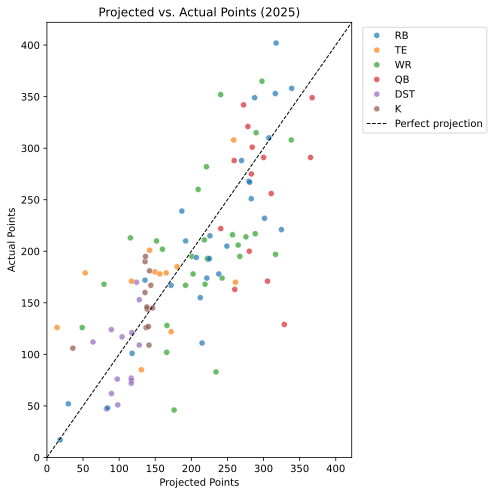

In [7]:
current_df = accuracy_df[accuracy_df["year"] == CURRENT_SEASON]

plt.figure(figsize=(7, 7))
sns.scatterplot(data=current_df, x="projected_points", y="actual_points", hue="position", alpha=0.7)
lims = [0, max(current_df["projected_points"].max(), current_df["actual_points"].max()) * 1.05]
plt.plot(lims, lims, "k--", linewidth=1, label="Perfect projection")
plt.xlim(lims)
plt.ylim(lims)
plt.xlabel("Projected Points")
plt.ylabel("Actual Points")
plt.title(f"Projected vs. Actual Points ({CURRENT_SEASON})")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig("../docs/charts/projection_accuracy_scatter.png")
plt.show()

## 5. Is accuracy improving over time?

RMSE and MAE by season, to see whether ESPN's projections have gotten better, worse, or
stayed flat across the seasons we have data for.

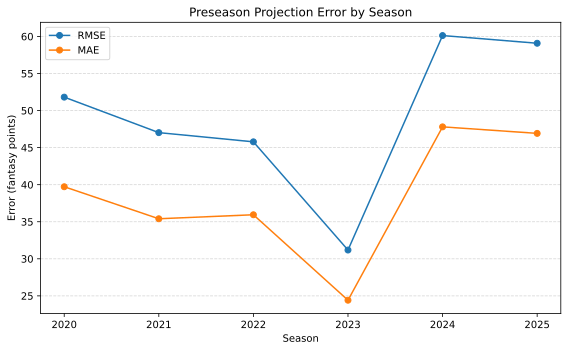

In [8]:
plt.figure(figsize=(8, 5))
plt.plot(by_year.index, by_year["rmse"], marker="o", label="RMSE")
plt.plot(by_year.index, by_year["mae"], marker="o", label="MAE")
plt.xlabel("Season")
plt.ylabel("Error (fantasy points)")
plt.title("Preseason Projection Error by Season")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("../docs/charts/projection_accuracy_trend.png")
plt.show()

## 6. Biggest misses (boom/bust), most recent season

The players projections got most wrong in `CURRENT_SEASON` - biggest positive `error`
(projected far more than they actually scored - "busts") and biggest negative `error`
(projected far less than they actually scored - "booms").

In [9]:
cols = ["player_name", "position", "pro_team", "projected_points", "actual_points", "error"]

busts = current_df.sort_values("error", ascending=False).head(10)[cols].reset_index(drop=True)
booms = current_df.sort_values("error", ascending=True).head(10)[cols].reset_index(drop=True)

boom_bust = pd.concat(
    [busts.assign(type="bust (overprojected)"), booms.assign(type="boom (underprojected)")],
    ignore_index=True,
)
boom_bust.to_html("../docs/tables/projection_boom_bust.html", index=False)

print("Busts (overprojected):")
display(busts)
print("Booms (underprojected):")
display(booms)

Busts (overprojected):


,player_name,position,pro_team,projected_points,actual_points,error
0,Joe Burrow,QB,CIN,328.76,129.0,199.76
1,Mike Evans,WR,TB,234.21,83.0,151.21
2,Brock Purdy,QB,SF,305.50,171.0,134.50
3,Jayden Reed,WR,GB,176.17,46.0,130.17
4,CeeDee Lamb,WR,DAL,316.60,197.0,119.60
5,Aaron Jones Sr.,RB,MIN,214.87,111.0,103.87
6,Saquon Barkley,RB,PHI,324.71,221.0,103.71
7,Geno Smith,QB,LV,260.15,163.0,97.15
8,Brock Bowers,TE,LV,261.14,170.0,91.14
9,C.J. Stroud,QB,HOU,280.25,200.0,80.25


Booms (underprojected):


,player_name,position,pro_team,projected_points,actual_points,error
0,Harold Fannin Jr.,TE,CLE,53.03,179.0,-125.97
1,Colby Parkinson,TE,LAR,14.08,126.0,-111.92
2,Jaxon Smith-Njigba,WR,SEA,240.65,352.0,-111.35
3,Michael Wilson,WR,ARI,115.61,213.0,-97.39
4,Troy Franklin,WR,DEN,79.04,168.0,-88.96
5,Christian McCaffrey,RB,SF,317.37,402.0,-84.63
6,Christian Watson,WR,GB,48.82,126.0,-77.18
7,Matt Prater,K,BUF,35.94,106.0,-70.06
8,Matthew Stafford,QB,LAR,272.30,342.0,-69.70
9,Puka Nacua,WR,LAR,297.81,365.0,-67.19


## 7. Takeaways

- Preseason projections carry real, position-dependent uncertainty - see the RMSE/MAE spread
  in the by-position table above. This is part of the justification for why the live draft
  tool's uncertainty bounds (NB04's bootstrap confidence intervals) matter: a single point
  projection understates how much a player's actual outcome can vary from what was projected.
- Position-level accuracy differences are a data point (not yet a code change) for anyone
  extending `src/scoring.py` further - e.g. widening `RECENCY_WEIGHT` or a future confidence
  discount for positions with historically higher projection error.
- This notebook is intentionally standalone: it isn't wired into `docs/index.qmd` or the live
  API this round, so re-running it doesn't affect the published site or the draft tool.